In [37]:
import os
import numpy as np
import rioxarray
from scipy.ndimage import correlate
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

import time

import gc
import ctypes
import tqdm, os

import xarray, rasterio, rioxarray
from rasterio.enums import Resampling

from skimage.filters.rank import mean_bilateral
from skimage.filters import correlate_sparse
from skimage.morphology import disk, dilation
from skimage.color import lab2rgb, rgb2lab, deltaE_cie76

from  skimage.util import img_as_ubyte 

from rio_cogeo import cog_translate
from rio_cogeo.profiles import cog_profiles
from morecantile import tms as TMS
from rasterio.transform import Affine 
import pandas as pd

from sklearn.metrics import mean_squared_error, r2_score

In [38]:
#Путь к файлу многоканального изображения
input_file_path = '/home/smetanina/NFS_WORK/data4dev/rkd_dev/kp_stat/8_correlation/test/EL2.2024-02-11T0600full_4km_dataset_1721357822.tiff'
# Используем относительный путь для сохранения файла в текущей директории
output_file_path = 'corr_example.tif'

In [39]:
def correlate_sparse_channels(tir, tresh=0.6, kernel_size=3):
    """Функция для корреляционного анализа между тепловым каналом и другим каналом многоканального изображения"""
    
    # Предположим, что тепловой канал — это 4 канал (индекс 3)
    thermal_channel = tir[7, :, :]
    
    # Выбор другого канала для анализа (используем каналы 1-14)
    ch2 = None
    for i in range(0, 13):  
        if np.any(tir[i, :, :]):
            ch2 = tir[i, :, :]
            break

    # Если другой канал не найден, возвращаем массив нулей
    if ch2 is None:
        return np.full((tir.shape[1], tir.shape[2]), 0, dtype=np.uint8)

    # Разреженная корреляция
    corr1 = correlate_sparse(thermal_channel, np.ones((kernel_size, kernel_size)), mode='reflect')
    corr2 = correlate_sparse(ch2, np.ones((kernel_size, kernel_size)), mode='reflect')

    # Нормализация корреляций
    corr1 = corr1 / np.nanmax(corr1) if np.nanmax(corr1) > 0 else corr1
    corr2 = corr2 / np.nanmax(corr2) if np.nanmax(corr2) > 0 else corr2

    # Вычисляем разницу между коррелированными изображениями
    corr3 = corr1 - corr2
    corr3 = corr3 / np.nanmax(corr3) if np.nanmax(corr3) > 0 else corr3

    # Применяем порог
    corr3[corr3 < tresh] = 0
    corr3[corr3 != 0] = 1

    return corr3.astype(np.uint8)

In [40]:
# Загрузка изображения
tir_data = rioxarray.open_rasterio(input_file_path, parse_coordinates=True).values

# Применяем функцию корреляции для обрезки облаков
cloud_mask = correlate_sparse_channels(tir_data)

# Применяем маску к исходным данным
cloud_free_data = tir_data * cloud_mask[np.newaxis, :, :]
print(cloud_free_data.shape)


(14, 8192, 8192)


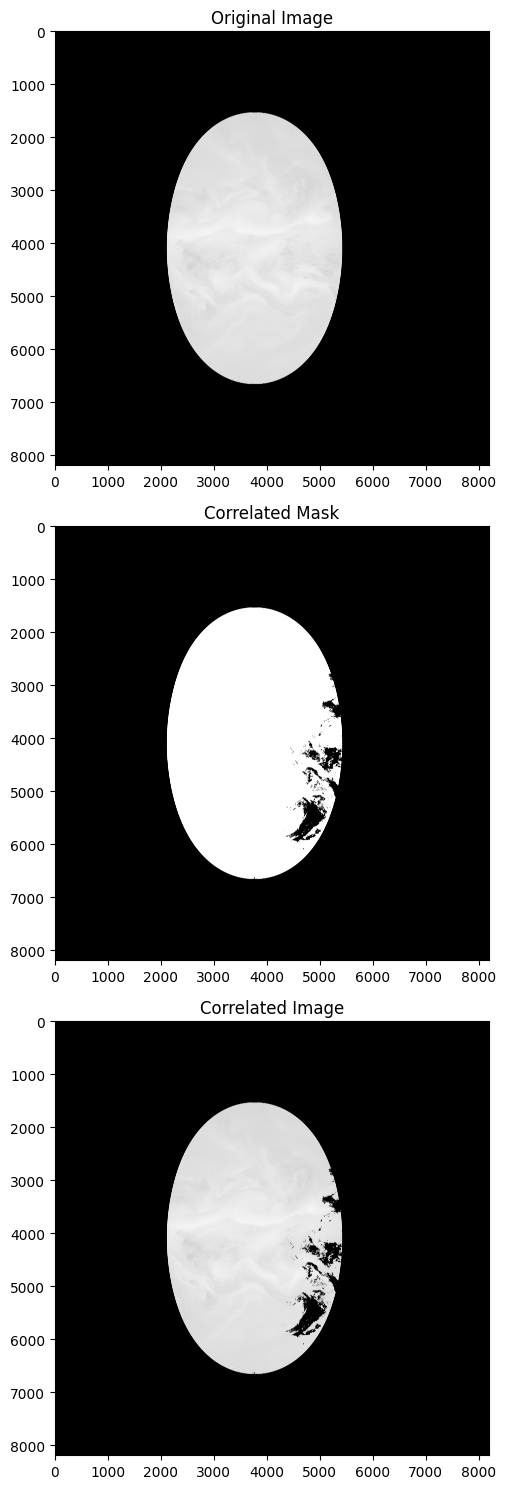

In [41]:
# Визуализация изображений
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 15))

# Отображаем оригинальные данные 
ax[0].imshow(tir_data[4], cmap='gray')
ax[0].set_title('Original Image')

# Отображаем маску облаков
ax[1].imshow(cloud_mask, cmap='gray')
ax[1].set_title('Correlated Mask')

# Отображаем изображение без облаков 
ax[2].imshow(cloud_free_data[4], cmap='gray')
ax[2].set_title('Correlated Image')

plt.tight_layout()
plt.show()


In [42]:
def save_geotiff(data, file_path, output_file):
    """
    Сохраняет массив данных в формате GeoTIFF.
    
    :param data: NumPy массив данных для сохранения.
    :param file_path: исходный растр.
    :param output_file: выходной файл.
    """
    # Получаем метаданные из исходного растра
    with rasterio.open(file_path) as src:
        meta = src.meta.copy()
        print(src.crs)
        
        # Получаем исходную трансформацию
        src_transform = src.transform
        
        # Расчет новых масштабов по оси X и Y
        new_scale_x = src_transform[0] * (src.width / data.shape[2])
        new_scale_y = src_transform[4] * (src.height / data.shape[1])
        
        # Создаем новую трансформацию с учетом новых масштабов
        new_transform = Affine.translation(src.transform.c, src.transform.f) * Affine.scale(new_scale_x, new_scale_y)
        
        # Обновляем метаданные для сохранения нового массива данных
        meta.update({
            'driver': 'GTiff',
            'height': data.shape[1],
            'width': data.shape[2],
            'count': 1,  # количество каналов
            'dtype': 'float32',  # или другой тип, в зависимости от ваших данных
            'crs': src.crs,
            'transform': new_transform,
            'compress': 'lzw'  # сжатие (по желанию)
        })

    # Извлекаем данные только из четвертого канала
    channel_4_data = data[3, :, :]  # Предполагается, что каналы индексируются с 0

    with rasterio.open(output_file, 'w', **meta) as dst:
        dst.write(channel_4_data, 1)  # Записываем одноканальное изображение

In [43]:
# Сохраняем полученное изображение без облаков в GeoTIFF
save_geotiff(cloud_free_data, input_file_path, output_file_path)
print(f"Изображение без облаков сохранено в {output_file_path}")

EPSG:3857
Изображение без облаков сохранено в corr_example.tif


In [44]:
# Исходные данные
data = [
    {"timestamp": "2024-02-11T06:00:00Z", "temperature": 2.27999997, "lat": 62.226, "lon": -2.114},
    {"timestamp": "2024-02-11T06:00:00Z", "temperature": -7.59, "lat": 75.576, "lon": -11.359},
    {"timestamp": "2024-02-11T07:00:00Z", "temperature": 24.0, "lat": 1.20, "lon": -11.10},
    {"timestamp": "2024-02-11T06:00:00Z", "temperature": 16.37000084, "lat": -42.881, "lon": 45.284},
    {"timestamp": "2024-02-11T06:00:00Z", "temperature": 21.37000084, "lat": 25.849, "lon": -44.732}
]

# Преобразуем в DataFrame
df = pd.DataFrame(data)

# Открываем данные с помощью rioxarray
data_arr = rioxarray.open_rasterio(output_file_path, parse_coordinates=True)
data_arr_4326 = data_arr.rio.reproject('EPSG:4326')


def get_point_data(lon, lat):
    """Получает данные точки с помощью метода sel и возвращает координаты."""
    point_data = data_arr_4326.sel(band=4, x=lon, y=lat, method='nearest').values
    if not point_data == 0:
        #print(point_data, (lon, lat))
        return point_data, (lon, lat)  # Возвращаем данные и координаты
    return None, None

def calculate_coefficients(points, temperatures):
    """Решает систему уравнений и возвращает коэффициенты a1 и a2."""
    A = np.array([[1, points[0]], [1, points[1]]])
    T = np.array([temperatures[0], temperatures[1]])
    a1, a2 = np.linalg.solve(A, T)
    print(f"Коэффициенты регрессии: {a1, a2}")
    return a1, a2

def check_temperature(third_point_data, a1, a2):
    """Предсказывает температуру для третьей точки и вычисляет ошибку."""
    predicted_temperature = a1 + a2 * third_point_data
    return predicted_temperature

def main():
    valid_points = []
    valid_temperatures = []
    valid_coordinates = []

    # Получаем значения из растровых данных и соответствующие температуры для всех точек
    for _, row in df.iterrows():
        lon = row['lon']
        lat = row['lat']
        
        point_value, coords = get_point_data(lon, lat)
        if point_value is not None:
            valid_points.append(point_value)
            valid_temperatures.append(row['temperature'])
            valid_coordinates.append(coords)  # Сохраняем координаты

    # Проверяем, достаточно ли данных для составления системы уравнений
    if len(valid_points) >= 2:
        a1, a2 = calculate_coefficients(valid_points[:2], valid_temperatures[:2])
        
        # Проверяем температуру для третьей точки (используем третью валидную точку)
        if len(valid_points) > 2:
            third_point_data = valid_points[2]
            actual_temperature = valid_temperatures[2]
            third_coords = valid_coordinates[2]  # Получаем координаты третьей точки
            
            predicted_temperature = check_temperature(third_point_data, a1, a2)
            
            # Вычисляем ошибку
            error = np.abs(predicted_temperature - actual_temperature)
            
            print(f"Координаты точки: {third_coords}")
            print(f"Предсказанная температура: {predicted_temperature:.2f}°C")
            print(f"Фактическая температура: {actual_temperature:.2f}°C")
            print(f"Ошибка: {error:.2f}°C")
        else:
            print("Недостаточно валидных точек для проверки температуры.")
    else:
        print("Недостаточно данных для составления системы уравнений.")

# Запуск основной функции
main()


Коэффициенты регрессии: (-160.80890450603113, 0.6502799136241736)
Координаты точки: (45.284, -42.881)
Предсказанная температура: 16.75°C
Фактическая температура: 16.37°C
Ошибка: 0.38°C


In [45]:
def save_geotiff2(data, file_path, output_file):
    """
    Сохраняет массив данных в формате GeoTIFF.
    
    :param data: NumPy массив данных для сохранения.
    :param file_path: исходный растр.
    :param output_file: выходной файл.
    """
    # Получаем метаданные из исходного растра
    with rasterio.open(file_path) as src:
        meta = src.meta.copy()
        print(src.crs)
        
        # Получаем исходную трансформацию
        src_transform = src.transform
        
        # Расчет новых масштабов по оси X и Y
        new_scale_x = src_transform[0] * (src.width / data.shape[2])
        new_scale_y = src_transform[4] * (src.height / data.shape[1])
        
        # Создаем новую трансформацию с учетом новых масштабов
        new_transform = Affine.translation(src.transform.c, src.transform.f) * Affine.scale(new_scale_x, new_scale_y)
        
        # Обновляем метаданные для сохранения нового массива данных
        meta.update({
            'driver': 'GTiff',
            'height': data.shape[1],
            'width': data.shape[2],
            'count': 1,  # количество каналов
            'dtype': 'float32',  # или другой тип, в зависимости от ваших данных
            'crs': src.crs,
            'transform': new_transform,
            'compress': 'lzw'  # сжатие (по желанию)
        })


    with rasterio.open(output_file, 'w', **meta) as dst:
        dst.write(data)  # Записываем одноканальное изображение

In [50]:

# Применяем формулу для предсказания температуры
predicted_temperature = a1 + a2 * data_arr

# Сохраняем результат в новый файл
output_file_path_predicted = 'predicted_temperature.tif'
save_geotiff2(predicted_temperature, input_file_path, output_file_path_predicted)
print(f"Изображение сохранено в {output_file_path_predicted}")


Loaded raster from corr_example.tif
raster <xarray.DataArray (band: 1, y: 8192, x: 8192)> Size: 268MB
[67108864 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 66kB -2.005e+07 -2.004e+07 ... 2.004e+07 2.005e+07
  * y            (y) float64 66kB 2.004e+07 2.003e+07 ... -2.003e+07 -2.004e+07
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     0.0
    scale_factor:   1.0
    add_offset:     0.0
nodata_old 0.0
(1, 820, 820)
EPSG:3857
Изображение сохранено в predicted_temperature.tif


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(19680801)

plt.subplot(211)
plt.imshow(temperaturw,  cmap = 'turbo')


plt.subplots_adjust(bottom=0.1, right=0.8, top=0.9)
cax = plt.axes((0, 0.1, 0.075, 2))
cbar = plt.colorbar(cax=cax, ticks=[-15, -10, -5, 0, 5, 10, 15, 20, 25, 30], drawedges = True, label='K', spacing = 'uniform')
plt.show()